In [21]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [22]:
amzn = pd.read_csv('AMZN_predictions.csv', parse_dates=['Date'], index_col='Date')
aapl = pd.read_csv('AAPL_predictions.csv', parse_dates=['Date'], index_col='Date')
googl = pd.read_csv('GOOGL_predictions.csv', parse_dates=['Date'], index_col='Date')
msft = pd.read_csv('MSFT_predictions.csv', parse_dates=['Date'], index_col='Date')
tsla = pd.read_csv('TSLA_predictions.csv', parse_dates=['Date'], index_col='Date')

In [43]:
# Merge predicted returns
returns_df = pd.concat([
    amzn['Predicted Return'].rename('AMZN'),
    aapl['Predicted Return'].rename('AAPL'),
    googl['Predicted Return'].rename('GOOGL'),
    msft['Predicted Return'].rename('MSFT'),
    tsla['Predicted Return'].rename('TSLA')
], axis=1).dropna()

# Annualize expected returns and covariance
expected_returns = returns_df.mean() * 252
cov_matrix = returns_df.cov() * 252

# Regularized Sharpe Ratio objective
def regularized_sharpe(weights, expected_returns, cov_matrix, lambda_reg=10):
    port_return = np.dot(weights, expected_returns)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe = port_return / port_vol
    penalty = lambda_reg * np.sum(weights**2)  # L2 penalty
    return -sharpe + penalty

# Constraints: sum(weights) = 1
constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}

# Bounds: force weights to be at least 1% (to avoid zeros)
bounds = [(0.01, 1) for _ in expected_returns]

# Initial weights: equally distributed
init_guess = [1 / len(expected_returns)] * len(expected_returns)

# Optimize
result = minimize(
    regularized_sharpe,
    init_guess,
    args=(expected_returns, cov_matrix, 10),  # you can tune lambda_reg
    bounds=bounds,
    constraints=constraints
)

# Extract optimal weights
optimal_weights = result.x
weights_named = dict(zip(expected_returns.index, optimal_weights))

# Optional: compute final Sharpe, return, volatility
port_return = np.dot(optimal_weights, expected_returns)
port_vol = np.sqrt(np.dot(optimal_weights.T, np.dot(cov_matrix, optimal_weights)))
sharpe_ratio = port_return / port_vol

c:\Python313\Lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


In [44]:
print("✅ Optimal Weights:")
for stock, weight in zip(expected_returns.index, optimal_weights):
    print(f"{stock}: {weight:.2%}")
print(f"\n📈 Expected Annual Return: {port_return:.2%}")
print(f"📉 Annual Volatility: {port_vol:.2%}")
print(f"📊 Sharpe Ratio: {sharpe_ratio:.2f}")

✅ Optimal Weights:
AMZN: 1.00%
AAPL: 13.83%
GOOGL: 22.15%
MSFT: 39.53%
TSLA: 23.49%

📈 Expected Annual Return: 88.28%
📉 Annual Volatility: 10.82%
📊 Sharpe Ratio: 8.16


In [45]:
def backtest_with_stop_loss(df, stop_loss_threshold=0.05, risk_free_rate=0.01):
    position = (df['Predicted Return'] > 0).astype(int)  # 1 if buy, 0 otherwise
    returns = df['Actual Return'] * position

    # Apply stop-loss
    cumulative = (1 + returns).cumprod()
    stop_loss_triggered = cumulative.pct_change().fillna(0) < -stop_loss_threshold
    returns[stop_loss_triggered] = -stop_loss_threshold  # Cap the loss

    # Sharpe Ratio
    excess_return = returns - risk_free_rate / 252  # Daily
    sharpe_ratio = np.mean(excess_return) / np.std(excess_return) * np.sqrt(252)
    
    return returns, sharpe_ratio

In [46]:
returns_df = pd.concat([
    amzn[['Predicted Return', 'Actual Return']].rename(columns={'Predicted Return': 'AMZN_Pred', 'Actual Return': 'AMZN_Ret'}),
    aapl[['Predicted Return', 'Actual Return']].rename(columns={'Predicted Return': 'AAPL_Pred', 'Actual Return': 'AAPL_Ret'}),
    googl[['Predicted Return', 'Actual Return']].rename(columns={'Predicted Return': 'GOOGL_Pred', 'Actual Return': 'GOOGL_Ret'}),
    msft[['Predicted Return', 'Actual Return']].rename(columns={'Predicted Return': 'MSFT_Pred', 'Actual Return': 'MSFT_Ret'}),
    tsla[['Predicted Return', 'Actual Return']].rename(columns={'Predicted Return': 'TSLA_Pred', 'Actual Return': 'TSLA_Ret'})
], axis=1).dropna()

# Extract weight vector in same order
weights = np.array([optimal_weights[i] for i in range(len(optimal_weights))])

# Predicted and actual return columns
pred_cols = ['AMZN_Pred', 'AAPL_Pred', 'GOOGL_Pred', 'MSFT_Pred', 'TSLA_Pred']
ret_cols = ['AMZN_Ret', 'AAPL_Ret', 'GOOGL_Ret', 'MSFT_Ret', 'TSLA_Ret']

# Matrix multiply to get daily portfolio return
returns_df['Predicted Return'] = returns_df[pred_cols].values @ weights
returns_df['Actual Return'] = returns_df[ret_cols].values @ weights

portfolio_returns, portfolio_sharpe = backtest_with_stop_loss(returns_df)
print(f"✅ Backtested Portfolio Sharpe Ratio: {portfolio_sharpe:.2f}")

✅ Backtested Portfolio Sharpe Ratio: 4.16


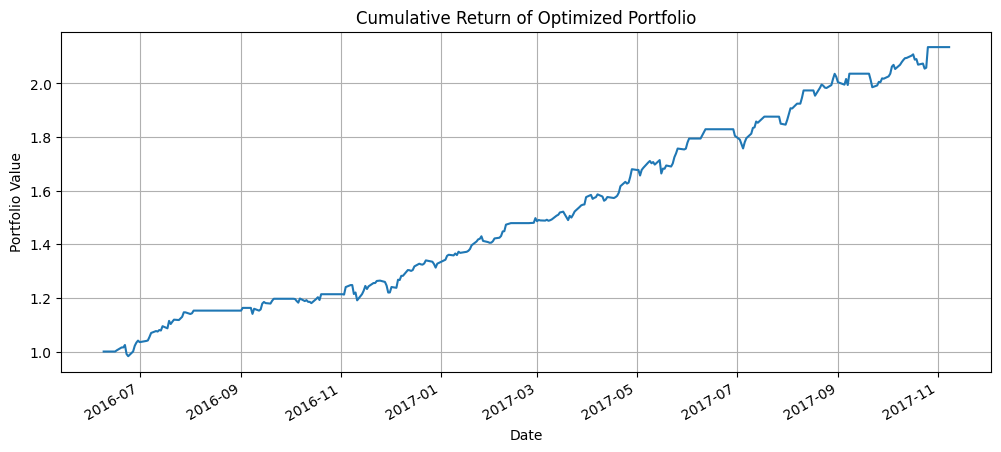

In [47]:
(1 + portfolio_returns).cumprod().plot(figsize=(12, 5), title="Cumulative Return of Optimized Portfolio")
plt.ylabel("Portfolio Value")
plt.grid(True)
plt.show()